In [169]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNetCV, RidgeCV
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, train_test_split

In [ ]:
df = pd.read_excel('data/healthcare_young.xlsx')
df.head()

,Age,Gender,Region,Marital_status,Number Of Dependants,BMI_Category,Smoking_Status,Employment_Status,Income_Level,Income_Lakhs,Medical History,Insurance_Plan,Annual_Premium_Amount
0,18,Male,Northeast,Unmarried,0,Overweight,Regular,Self-Employed,> 40L,99,High blood pressure,Silver,13365
1,22,Female,Northwest,Unmarried,0,Underweight,No Smoking,Freelancer,<10L,3,No Disease,Silver,11050
2,21,Female,Southeast,Unmarried,0,Normal,Regular,Salaried,> 40L,97,No Disease,Silver,11857
3,25,Male,Southeast,Unmarried,0,Normal,No Smoking,Freelancer,10L - 25L,15,No Disease,Bronze,5684
4,20,Male,Southeast,Unmarried,2,Overweight,No Smoking,Freelancer,10L - 25L,14,No Disease,Bronze,5712


In [171]:
df.shape

(20096, 13)

In [269]:
df.columns

Index(['age', 'gender', 'region', 'marital_status', 'number_of_dependants',
       'bmi_category', 'smoking_status', 'employment_status', 'income_level',
       'income_lakhs', 'medical_history', 'insurance_plan',
       'annual_premium_amount'],
      dtype='object')

In [173]:
df.columns = df.columns.str.replace(' ', '_').str.lower()
df.head(1)

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount
0,18,Male,Northeast,Unmarried,0,Overweight,Regular,Self-Employed,> 40L,99,High blood pressure,Silver,13365


<h2 align="center">🧹 Data Cleaning</h2>

### Handle Missing Values

In [174]:
df.isna().sum()

age                      0
gender                   0
region                   0
marital_status           0
number_of_dependants     0
bmi_category             0
smoking_status           2
employment_status        1
income_level             4
income_lakhs             0
medical_history          0
insurance_plan           0
annual_premium_amount    0
dtype: int64

In [175]:
df.dropna(inplace=True)
df.isna().sum()

age                      0
gender                   0
region                   0
marital_status           0
number_of_dependants     0
bmi_category             0
smoking_status           0
employment_status        0
income_level             0
income_lakhs             0
medical_history          0
insurance_plan           0
annual_premium_amount    0
dtype: int64

### Handle Duplicates

In [176]:
df.duplicated().sum()

np.int64(0)

In [177]:
df.drop_duplicates(inplace=True)
df.duplicated().sum()

np.int64(0)

In [178]:
df.describe()

,age,number_of_dependants,income_lakhs,annual_premium_amount
count,20090.000000,20090.000000,20090.000000,20090.000000
mean,21.494375,0.718019,22.510851,8142.096267
std,2.294052,0.940713,23.420493,2749.906347
min,18.000000,-3.000000,1.000000,3501.000000
25%,19.000000,0.000000,6.000000,6022.250000
50%,22.000000,0.000000,16.000000,7939.000000
75%,23.000000,1.000000,31.000000,9561.000000
max,25.000000,3.000000,790.000000,18186.000000


#### Data Cleaning: Handle number_of_dependants

In [179]:
df['number_of_dependants'].value_counts().unique

<bound method Series.unique of number_of_dependants
 0    10856
 1     5467
 2     2231
 3     1514
-3       12
-1       10
Name: count, dtype: int64>

In [180]:
df[df.number_of_dependants < 0 ]['number_of_dependants'].unique()

array([-3, -1])

In [181]:
df['number_of_dependants'] = df['number_of_dependants'].abs()

df['number_of_dependants'].describe()

count    20090.000000
mean         0.722598
std          0.937200
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max          3.000000
Name: number_of_dependants, dtype: float64

In [182]:
df.describe()

,age,number_of_dependants,income_lakhs,annual_premium_amount
count,20090.000000,20090.000000,20090.000000,20090.000000
mean,21.494375,0.722598,22.510851,8142.096267
std,2.294052,0.937200,23.420493,2749.906347
min,18.000000,0.000000,1.000000,3501.000000
25%,19.000000,0.000000,6.000000,6022.250000
50%,22.000000,0.000000,16.000000,7939.000000
75%,23.000000,1.000000,31.000000,9561.000000
max,25.000000,3.000000,790.000000,18186.000000


### Handle Numeric Columns

In [183]:
numeric_columns = df.select_dtypes(include=['float64', 'int64']).columns
numeric_columns

Index(['age', 'number_of_dependants', 'income_lakhs', 'annual_premium_amount'], dtype='object')

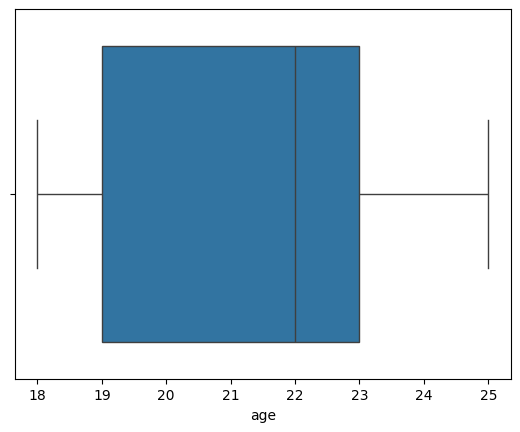

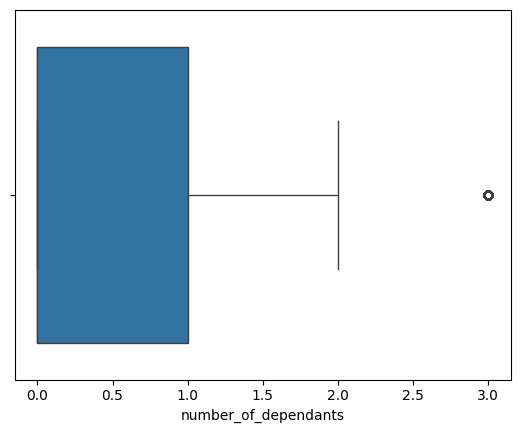

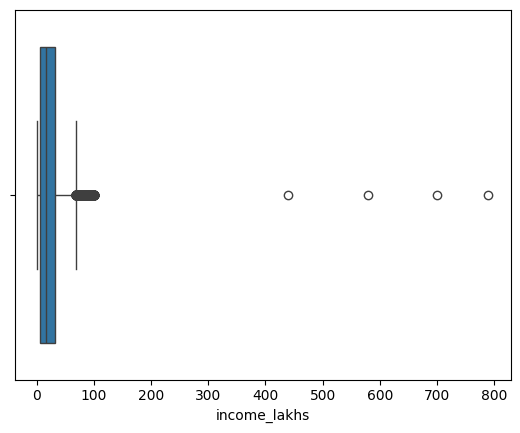

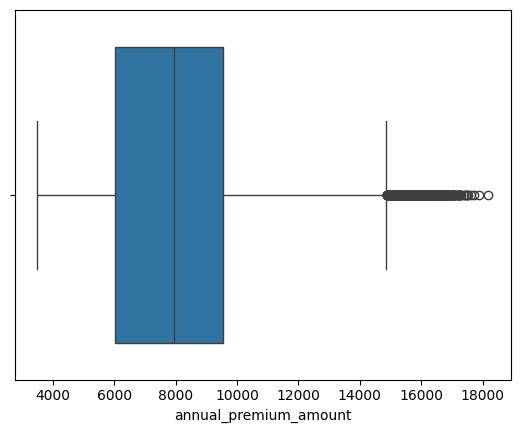

In [184]:
for col in numeric_columns:
    sns.boxplot(x=df[col])
    plt.show()

### Hanlde Outlier: Age Column

In [185]:
df[df['age'] > 100]['age'].value_counts()

Series([], Name: count, dtype: int64)

In [186]:
df[df['age'] > 100]['age'].unique()

array([], dtype=int64)

In [187]:
df[df['age'] > 100]['age'].value_counts().unique()

array([], dtype=int64)

In [188]:
df[df['age'] > 100]['age'].value_counts()

Series([], Name: count, dtype: int64)

In [189]:
df[df['age'] >= 100].shape[0]

0

In [190]:
df1 = df[df['age'] < 100]
df1.age.describe()

count    20090.000000
mean        21.494375
std          2.294052
min         18.000000
25%         19.000000
50%         22.000000
75%         23.000000
max         25.000000
Name: age, dtype: float64

### Handle Outlier: Income Column

<Axes: xlabel='income_lakhs', ylabel='Count'>

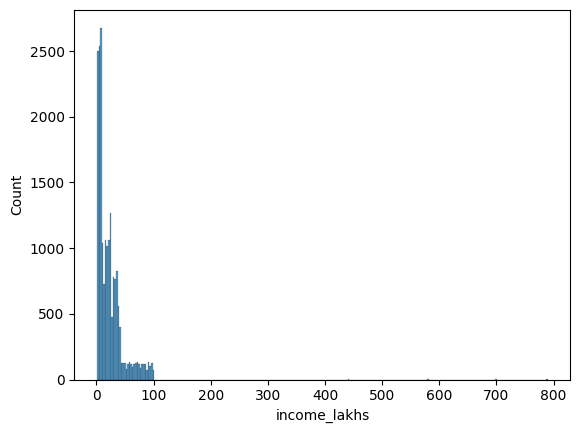

In [191]:
sns.histplot(df.income_lakhs)

In [192]:
df.income_lakhs.quantile([0.25, 0.75])

0.25     6.0
0.75    31.0
Name: income_lakhs, dtype: float64

In [193]:
def get_iqr_bounds(col):
    Q1, Q3 = col.quantile([0.25, 0.75])
    IQR = Q3-Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return lower_bound, upper_bound

lower, upper = get_iqr_bounds(df1['income_lakhs'])
lower, upper



(-31.5, 68.5)

In [194]:
df1[df1.income_lakhs>upper].shape

(1295, 13)

#### Upper bound value 67 is not too much high, we can be decided correct upper bound after dicussion with manager 


In [195]:
quantile_thresold = df1.income_lakhs.quantile(0.999)
quantile_thresold

np.float64(100.0)

In [196]:
df1[df1.income_lakhs > quantile_thresold].shape

(4, 13)

In [197]:
df2 = df1[df1.income_lakhs<=quantile_thresold].copy()
df2.shape

(20086, 13)

In [198]:
df2.describe()

,age,number_of_dependants,income_lakhs,annual_premium_amount
count,20086.000000,20086.000000,20086.000000,20086.000000
mean,21.494474,0.722742,22.390371,8141.799263
std,2.294248,0.937238,21.732062,2749.912486
min,18.000000,0.000000,1.000000,3501.000000
25%,19.000000,0.000000,6.000000,6022.000000
50%,22.000000,0.000000,16.000000,7939.000000
75%,23.000000,1.000000,31.000000,9561.000000
max,25.000000,3.000000,100.000000,18186.000000


<Axes: xlabel='income_lakhs', ylabel='Count'>

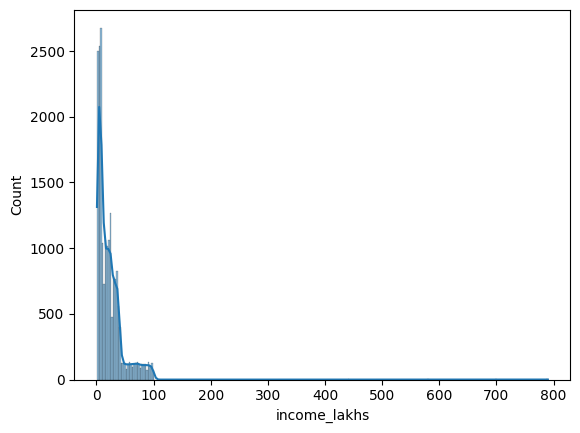

In [199]:
sns.histplot(df1['income_lakhs'], kde=True)

<Axes: xlabel='income_lakhs', ylabel='Count'>

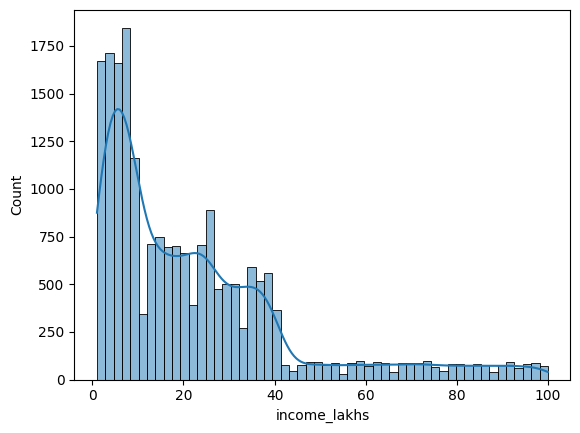

In [200]:
sns.histplot(df2['income_lakhs'], kde=True)

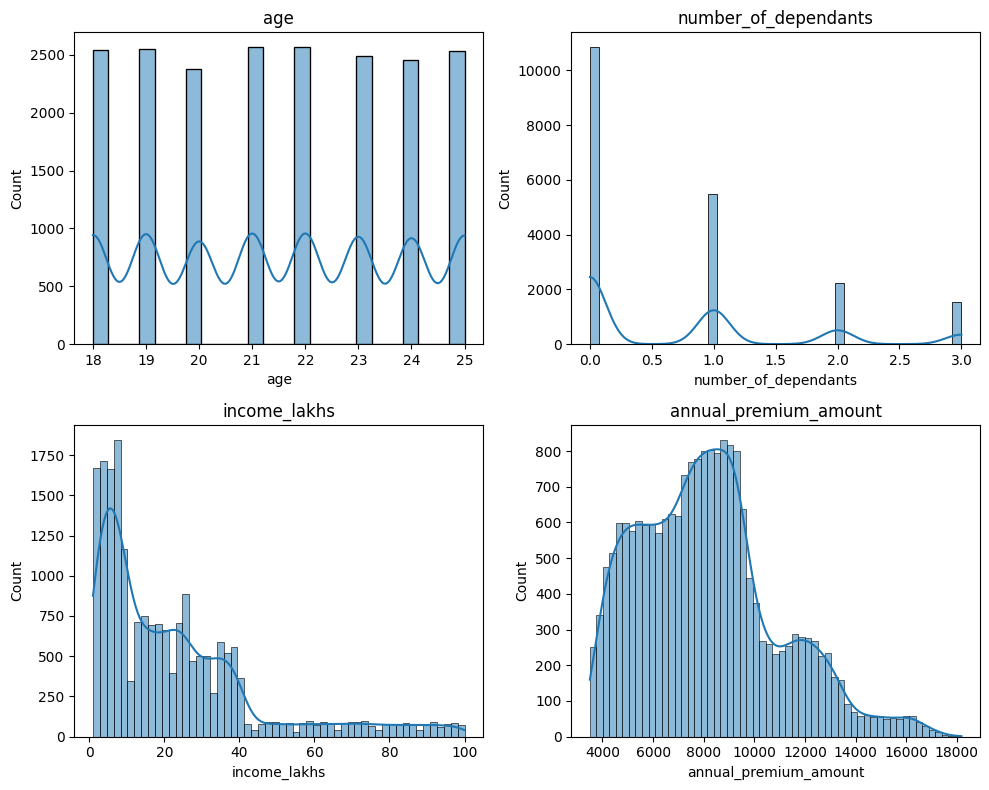

In [201]:
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(10, 8))  # Adjust the size as necessary

for i, column in enumerate(numeric_columns):
    ax = axs[i//2, i%2]  # Determines the position of the subplot in the grid
    sns.histplot(df2[column], kde=True, ax=ax)
    ax.set_title(column)

plt.tight_layout()
plt.show()

### Bivariate Analysis: Numeric Columns

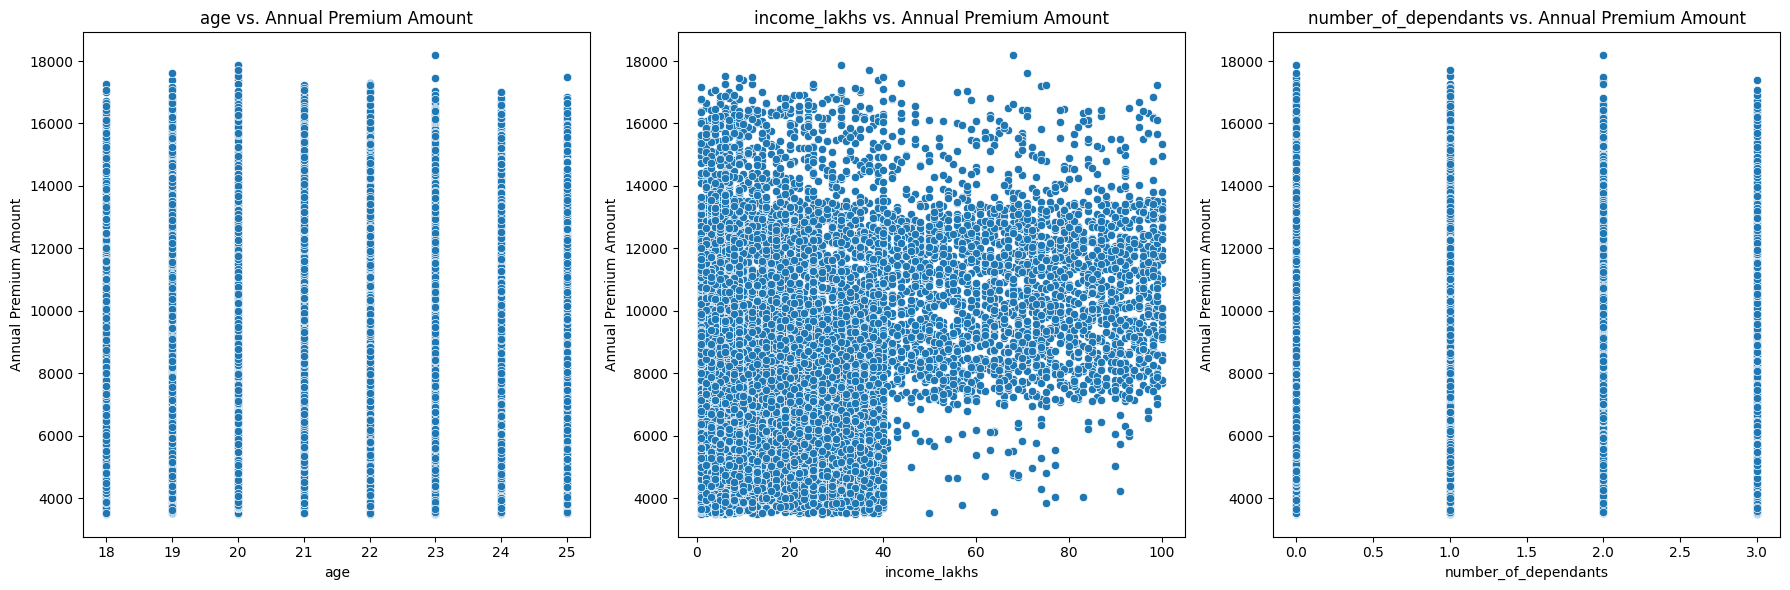

In [202]:
numeric_features = ['age', 'income_lakhs', 'number_of_dependants']

fig, axes = plt.subplots(1, len(numeric_features), figsize=(18, 6))  # Adjust figure size as necessary

for ax, column in zip(axes, numeric_features):
    sns.scatterplot(x=df2[column], y=df2['annual_premium_amount'], ax=ax)
    ax.set_title(f'{column} vs. Annual Premium Amount')
    ax.set_xlabel(column)
    ax.set_ylabel('Annual Premium Amount')

plt.tight_layout()  # Adjust layout
plt.show()

### EDA on Categorical Columns

In [203]:
categorical_cols = ['gender', 'region', 'marital_status', 'bmi_category', 'smoking_status', 'employment_status', 'income_level', 'medical_history', 'insurance_plan']
for col in categorical_cols:
    print(col, ":", df2[col].unique())

gender : ['Male' 'Female']
region : ['Northeast' 'Northwest' 'Southeast' 'Southwest']
marital_status : ['Unmarried' 'Married']
bmi_category : ['Overweight' 'Underweight' 'Normal' 'Obesity']
smoking_status : ['Regular' 'No Smoking' 'Occasional' 'Smoking=0' 'Does Not Smoke'
 'Not Smoking']
employment_status : ['Self-Employed' 'Freelancer' 'Salaried']
income_level : ['> 40L' '<10L' '10L - 25L' '25L - 40L']
medical_history : ['High blood pressure' 'No Disease' 'Diabetes & High blood pressure'
 'Diabetes & Heart disease' 'Diabetes' 'Diabetes & Thyroid'
 'Heart disease' 'Thyroid' 'High blood pressure & Heart disease']
insurance_plan : ['Silver' 'Bronze' 'Gold']


In [204]:
df2['smoking_status'] = df2['smoking_status'].replace({
    'Not Smoking': 'No Smoking',
    'Does Not Smoke': 'No Smoking',
    'Smoking=0': 'No Smoking'
})

df2['smoking_status'].unique()

array(['Regular', 'No Smoking', 'Occasional'], dtype=object)

### Univariate Analysis

In [205]:
df2.head(2)

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount
0,18,Male,Northeast,Unmarried,0,Overweight,Regular,Self-Employed,> 40L,99,High blood pressure,Silver,13365
1,22,Female,Northwest,Unmarried,0,Underweight,No Smoking,Freelancer,<10L,3,No Disease,Silver,11050


In [206]:
pct_count = df2['gender'].value_counts(normalize=True)*100
pct_count

gender
Male      55.038335
Female    44.961665
Name: proportion, dtype: float64

<Axes: xlabel='gender'>

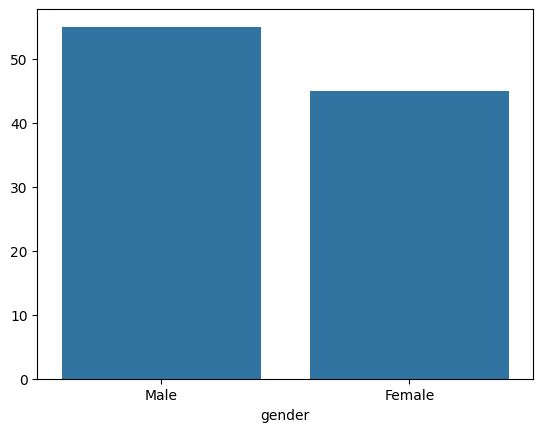

In [207]:
sns.barplot(x=pct_count.index, y=pct_count.values)

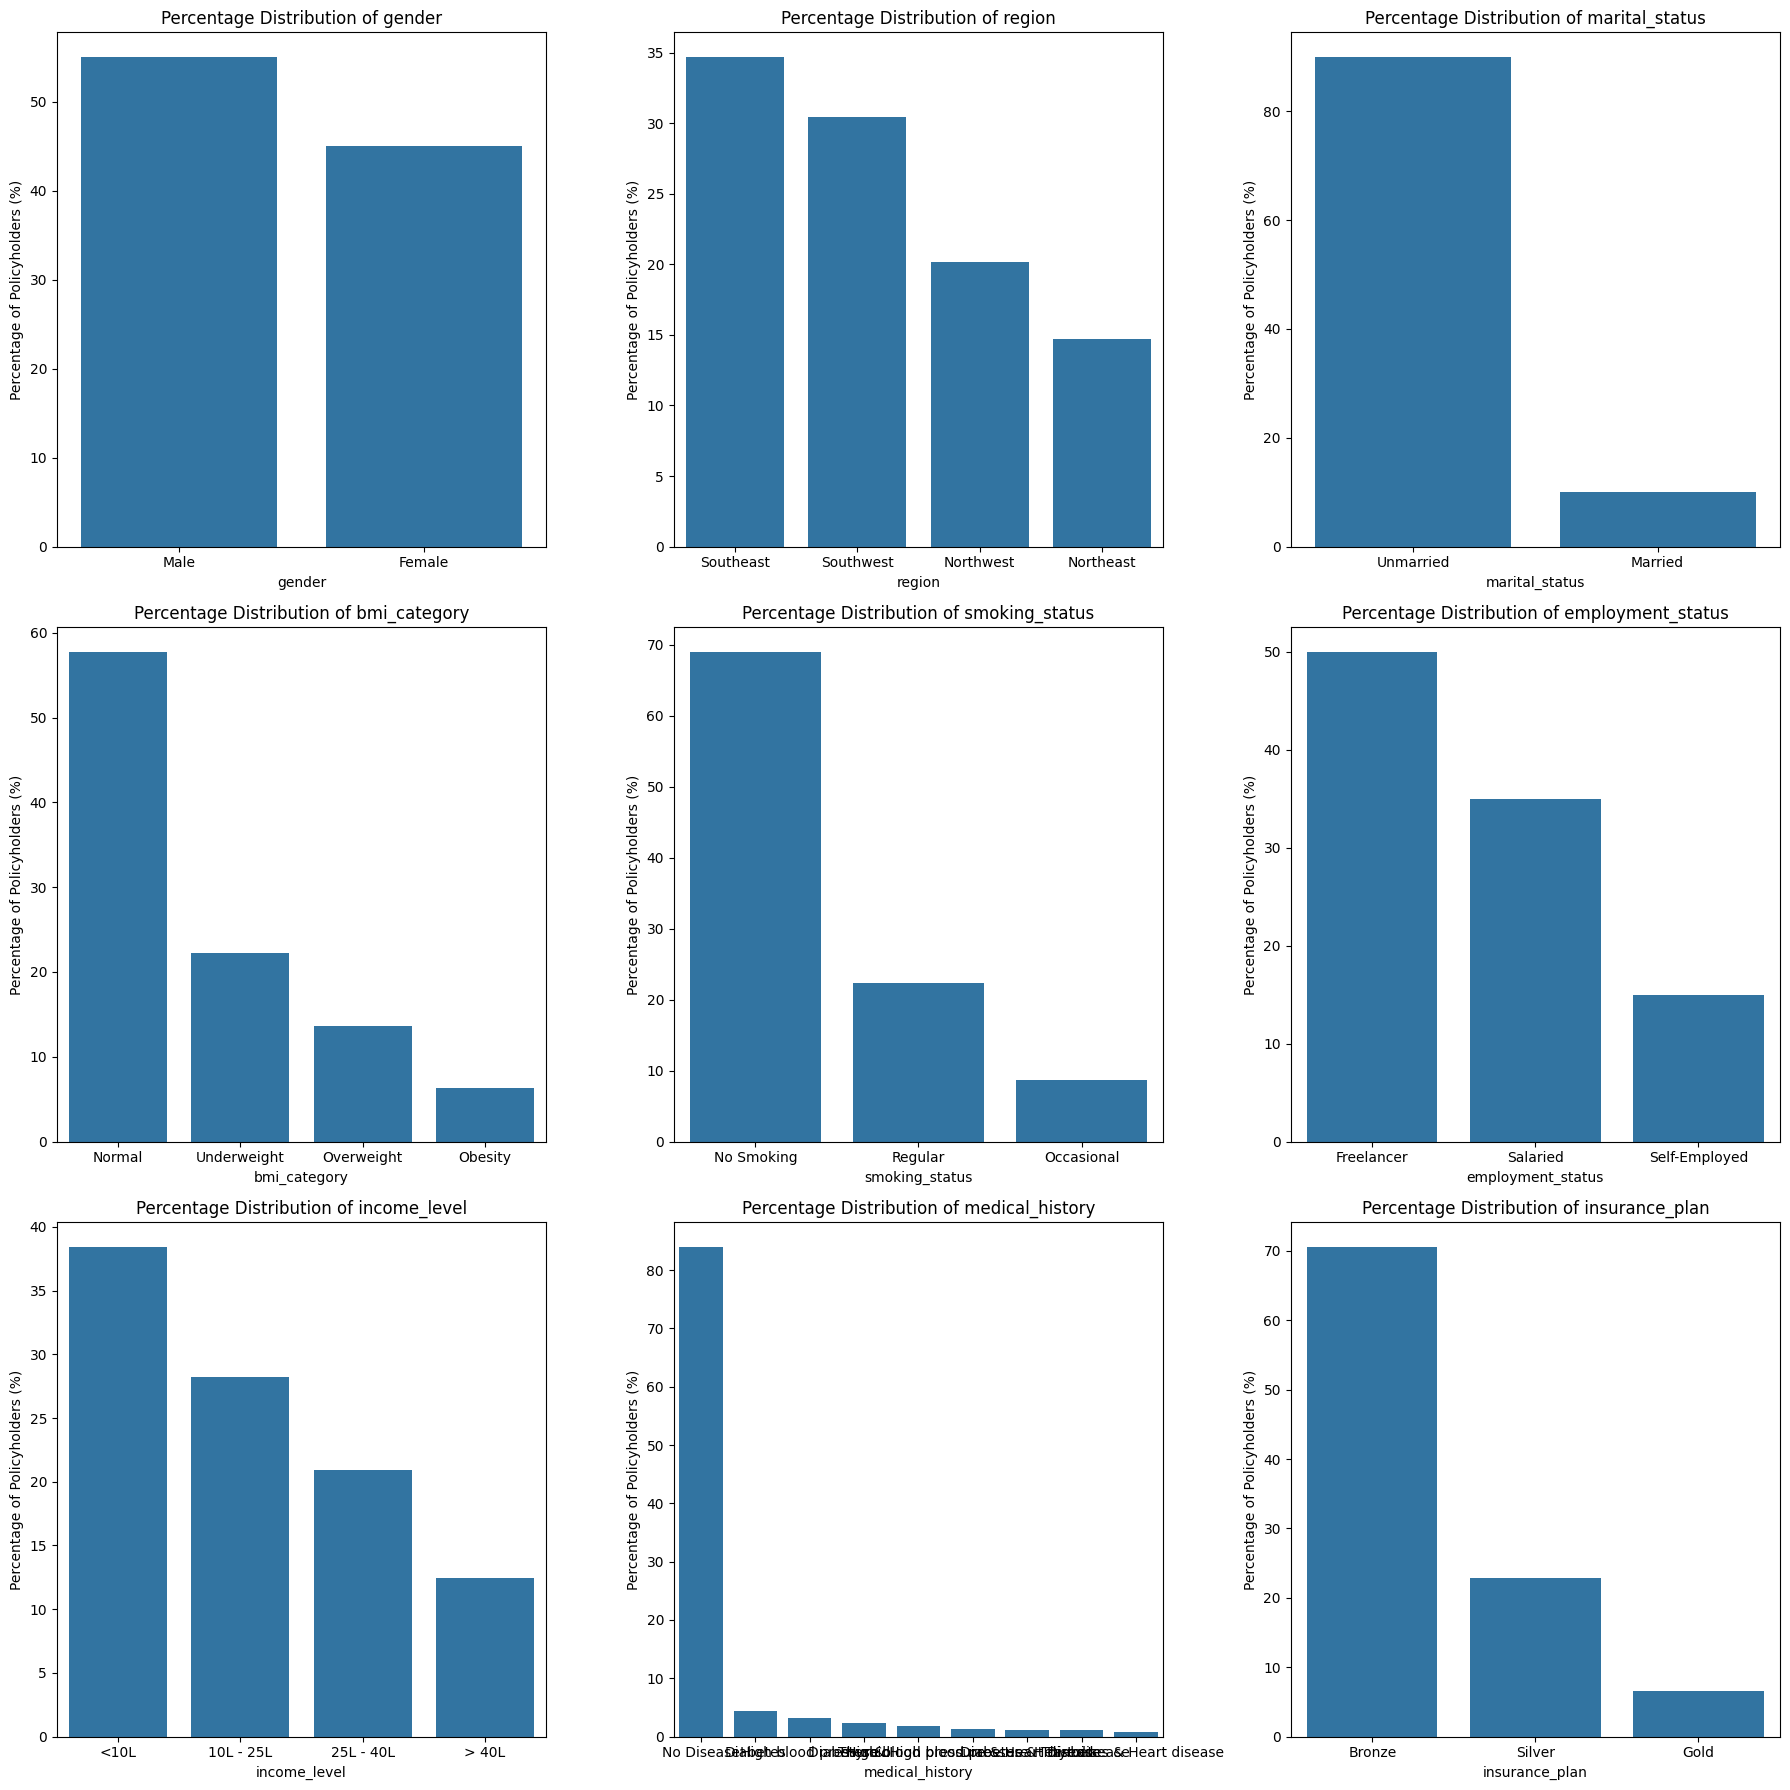

In [208]:
fig, axes = plt.subplots(3, 3, figsize=(18, 18))  # Adjust figure size as necessary
axes = axes.flatten()  # Flatten the 2D array of axes into 1D for easier iteration

for ax, column in zip(axes, categorical_cols):
    # Calculate the percentage distribution of each category
    category_counts = df2[column].value_counts(normalize=True) * 100  # normalize=True gives the relative frequencies
    
    # Plotting the distribution using barplot
    sns.barplot(x=category_counts.index, y=category_counts.values, ax=ax)
    ax.set_title(f'Percentage Distribution of {column}')
    ax.set_ylabel('Percentage of Policyholders (%)')
    ax.set_xlabel(column)  # Set xlabel to the column name for clarity

plt.tight_layout()  # Adjusts plot parameters for better fit in the figure window
plt.show()

### Bivariate Analysis

insurance_plan  Bronze  Gold  Silver
income_level                        
10L - 25L         4508   326     828
25L - 40L         3382   209     608
<10L              6172   404    1145
> 40L              115   366    2023


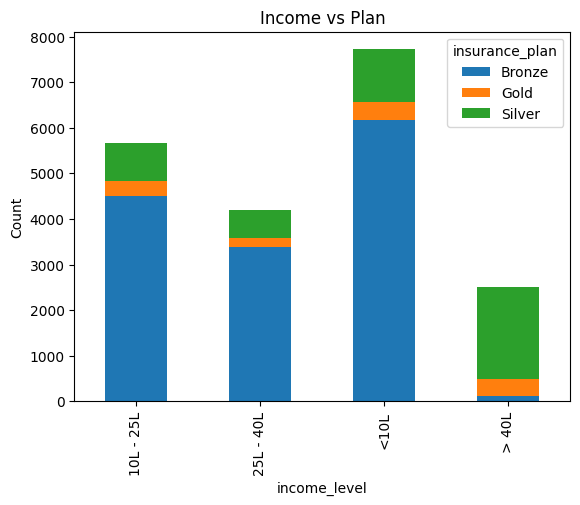

In [209]:
# Cross-tabulation of gender and smoking status
crosstab = pd.crosstab(df2['income_level'], df2['insurance_plan'])
print(crosstab)

# Plotting the crosstab
crosstab.plot(kind='bar', stacked=True)
plt.title('Income vs Plan')
plt.ylabel('Count')
plt.show()

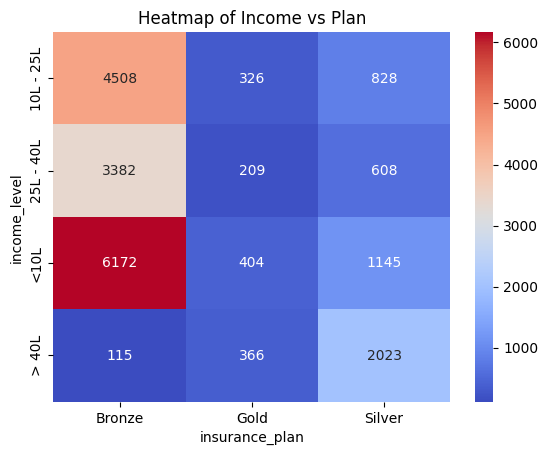

In [210]:
sns.heatmap(crosstab, annot=True, cmap='coolwarm',fmt="d")
plt.title('Heatmap of Income vs Plan')
plt.show()

<h2 align="center">🔧 Feature Engineering</h2>

In [211]:
df2.head(2)

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount
0,18,Male,Northeast,Unmarried,0,Overweight,Regular,Self-Employed,> 40L,99,High blood pressure,Silver,13365
1,22,Female,Northwest,Unmarried,0,Underweight,No Smoking,Freelancer,<10L,3,No Disease,Silver,11050


In [212]:
df.medical_history.unique()

array(['High blood pressure', 'No Disease',
       'Diabetes & High blood pressure', 'Diabetes & Heart disease',
       'Diabetes', 'Diabetes & Thyroid', 'Heart disease', 'Thyroid',
       'High blood pressure & Heart disease'], dtype=object)

### Process medical_history: Assign risk scores and normalize total score

In [213]:
# Define the risk scores for each condition
risk_scores = {
    "diabetes": 6,
    "heart disease": 8,
    "high blood pressure":6,
    "thyroid": 5,
    "no disease": 0,
    "none":0
}

df2[['disease1', 'disease2']] = df2['medical_history'].str.split(" & ", expand=True).apply(lambda x: x.str.lower())
df2['disease1'] = df2['disease1'].fillna('none')
df2['disease2'] = df2['disease2'].fillna('none')
df2['total_risk_score'] = 0

for disease in ['disease1', 'disease2']:
    df2['total_risk_score'] += df2[disease].map(risk_scores)


# Normalize the risk score to a range of 0 to 1
max_score = df2['total_risk_score'].max()
min_score = df2['total_risk_score'].min()
df2['normalized_risk_score'] = (df2['total_risk_score'] - min_score) / (max_score - min_score)
df2.sample(5)

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,disease1,disease2,total_risk_score,normalized_risk_score
2901,19,Male,Northwest,Unmarried,1,Normal,No Smoking,Freelancer,25L - 40L,26,No Disease,Bronze,7984,no disease,none,0,0.000000
4733,24,Male,Northeast,Unmarried,0,Overweight,No Smoking,Salaried,10L - 25L,20,No Disease,Gold,11589,no disease,none,0,0.000000
8981,24,Male,Northeast,Unmarried,1,Normal,Regular,Freelancer,25L - 40L,34,No Disease,Bronze,4631,no disease,none,0,0.000000
15057,22,Male,Southwest,Unmarried,0,Overweight,No Smoking,Freelancer,<10L,1,No Disease,Bronze,7604,no disease,none,0,0.000000
16010,18,Female,Southeast,Unmarried,0,Normal,No Smoking,Salaried,<10L,4,Diabetes & High blood pressure,Bronze,9284,diabetes,high blood pressure,12,0.857143


### Encode insurance_plan as Ordinal Numeric Values

In [214]:
df2['insurance_plan'].unique()

array(['Silver', 'Bronze', 'Gold'], dtype=object)

In [215]:
df2['insurance_plan'] = df2['insurance_plan'].map({'Bronze': 1, 'Silver': 2, 'Gold': 3})

### Encode income_level as Ordinal Numeric Values

In [216]:
df2.income_level.unique()

array(['> 40L', '<10L', '10L - 25L', '25L - 40L'], dtype=object)

In [217]:
df2['income_level'] = df2['income_level'].map({'<10L':1, '10L - 25L': 2, '25L - 40L':3, '> 40L':4})

In [218]:
nominal_cols = ['gender', 'region', 'marital_status', 'bmi_category', 'smoking_status', 'employment_status']
df3 = pd.get_dummies(df2, columns=nominal_cols, drop_first=True, dtype=int)
df3.head(3)

,age,number_of_dependants,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,disease1,disease2,total_risk_score,...,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
0,18,0,4,99,High blood pressure,2,13365,high blood pressure,none,6,...,0,0,1,0,1,0,0,1,0,1
1,22,0,1,3,No Disease,2,11050,no disease,none,0,...,0,0,1,0,0,1,0,0,0,0
2,21,0,4,97,No Disease,2,11857,no disease,none,0,...,1,0,1,0,0,0,0,1,1,0


In [219]:
df3.columns

Index(['age', 'number_of_dependants', 'income_level', 'income_lakhs',
       'medical_history', 'insurance_plan', 'annual_premium_amount',
       'disease1', 'disease2', 'total_risk_score', 'normalized_risk_score',
       'gender_Male', 'region_Northwest', 'region_Southeast',
       'region_Southwest', 'marital_status_Unmarried', 'bmi_category_Obesity',
       'bmi_category_Overweight', 'bmi_category_Underweight',
       'smoking_status_Occasional', 'smoking_status_Regular',
       'employment_status_Salaried', 'employment_status_Self-Employed'],
      dtype='object')

In [220]:
df4 = df3.drop(['medical_history','disease1', 'disease2', 'total_risk_score'], axis=1)
df4.head(3)                

,age,number_of_dependants,income_level,income_lakhs,insurance_plan,annual_premium_amount,normalized_risk_score,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
0,18,0,4,99,2,13365,0.428571,1,0,0,0,1,0,1,0,0,1,0,1
1,22,0,1,3,2,11050,0.000000,0,1,0,0,1,0,0,1,0,0,0,0
2,21,0,4,97,2,11857,0.000000,0,0,1,0,1,0,0,0,0,1,1,0


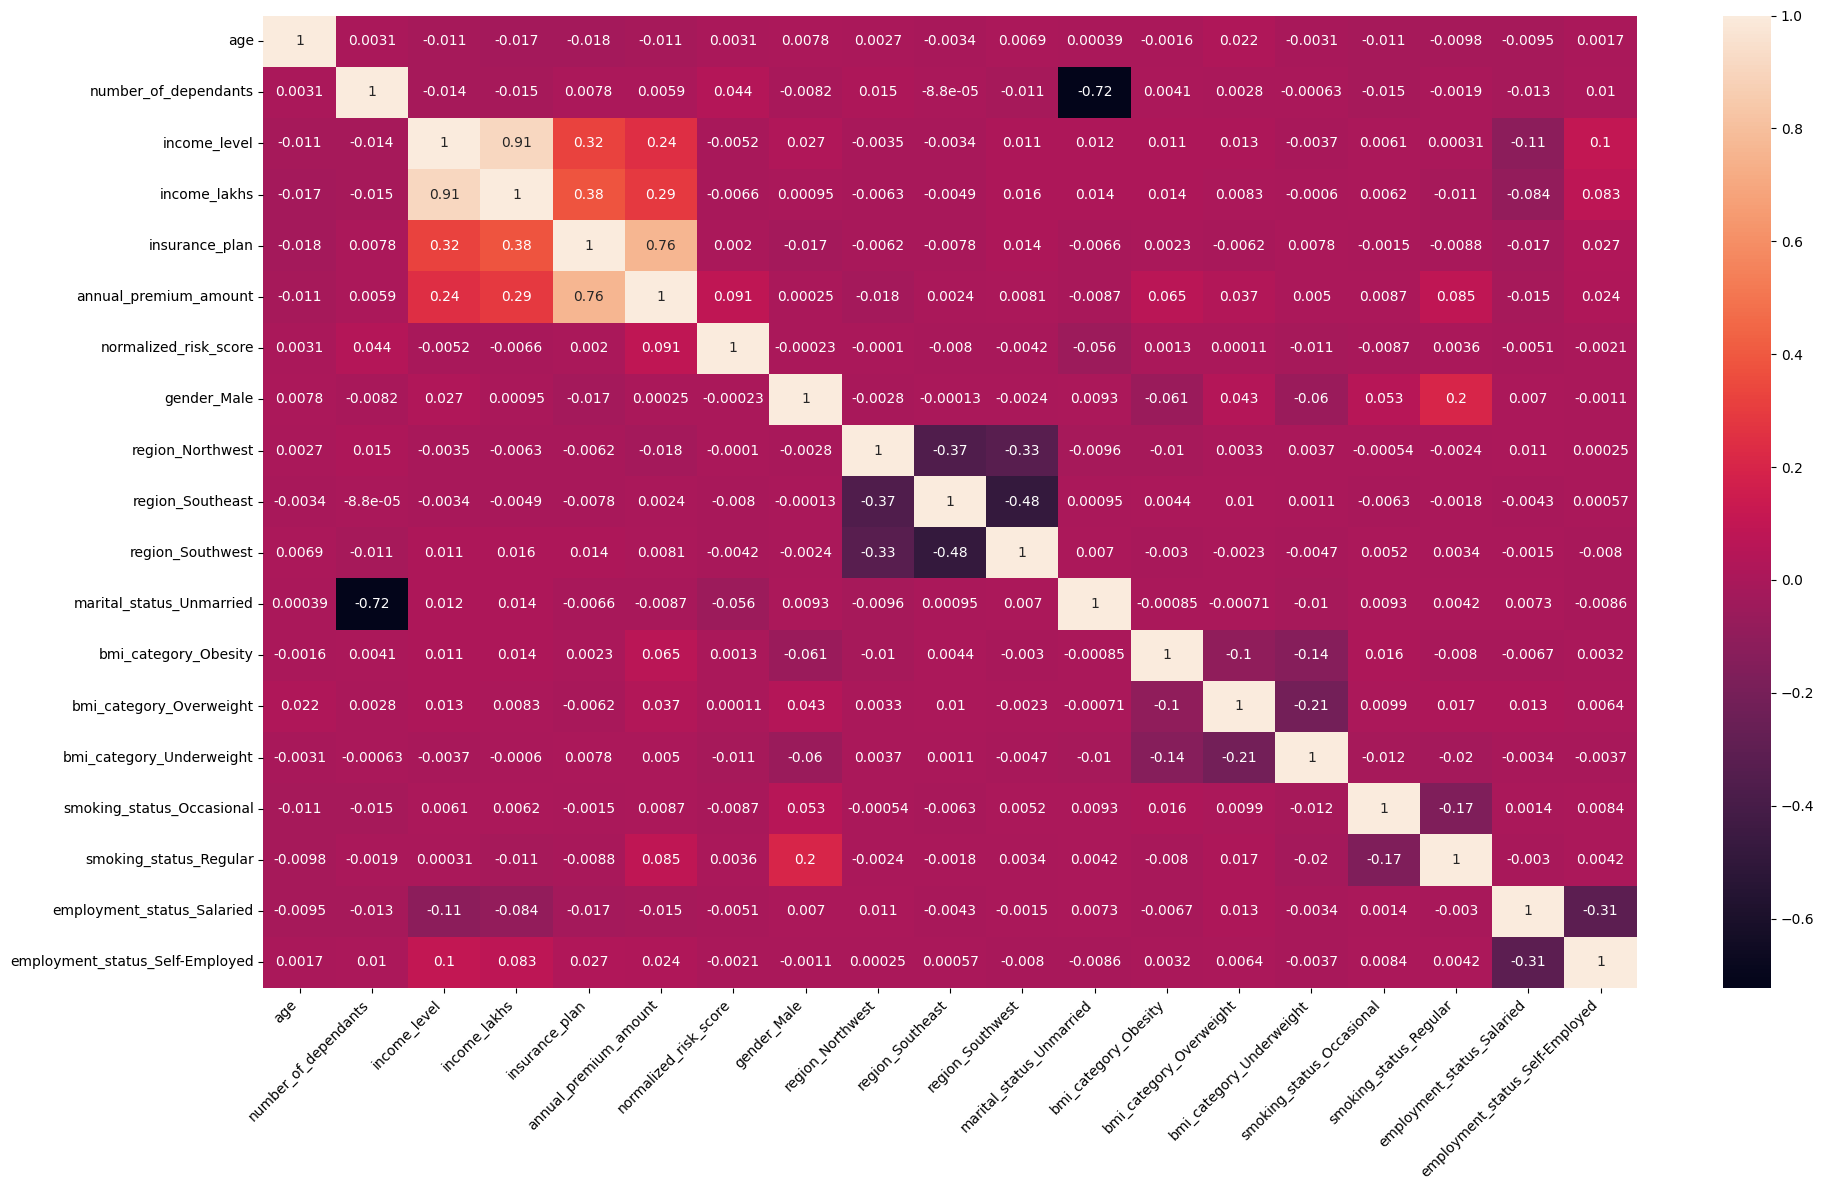

In [221]:
cm = df4.corr()

plt.figure(figsize=(20,12))
sns.heatmap(cm, annot=True)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


### Calculate VIF for Multicolinearity

In [222]:
X = df4.drop('annual_premium_amount', axis='columns')
y = df4['annual_premium_amount']

from sklearn.preprocessing import MinMaxScaler

cols_to_scale = ['age','number_of_dependants', 'income_level',  'income_lakhs', 'insurance_plan']
scaler = MinMaxScaler()

X[cols_to_scale] = scaler.fit_transform(X[cols_to_scale])
X.describe()

,age,number_of_dependants,income_level,income_lakhs,insurance_plan,normalized_risk_score,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
count,20086.000000,20086.000000,20086.000000,20086.000000,20086.000000,20086.000000,20086.000000,20086.000000,20086.000000,20086.000000,20086.000000,20086.000000,20086.000000,20086.000000,20086.000000,20086.000000,20086.000000,20086.000000
mean,0.499211,0.240914,0.357994,0.216064,0.179578,0.092076,0.550383,0.201284,0.346958,0.304590,0.899881,0.063527,0.136513,0.222493,0.086379,0.223589,0.350045,0.149955
std,0.327750,0.312413,0.347481,0.219516,0.300051,0.230016,0.497467,0.400970,0.476014,0.460245,0.300167,0.243914,0.343341,0.415931,0.280929,0.416660,0.476996,0.357036
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.142857,0.000000,0.000000,0.050505,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.571429,0.000000,0.333333,0.151515,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.714286,0.333333,0.666667,0.303030,0.500000,0.000000,1.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [223]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

def calculate_vif(data):
    vif_df = pd.DataFrame()
    vif_df['Column'] = data.columns
    vif_df['VIF'] = [variance_inflation_factor(data.values,i) for i in range(data.shape[1])]
    return vif_df

In [224]:
calculate_vif(X) # drop one col which VIF is too high like below drop income_level column

,Column,VIF
0,age,3.142881
1,number_of_dependants,1.860761
2,income_level,11.928707
3,income_lakhs,11.874242
4,insurance_plan,1.592892
5,normalized_risk_score,1.154223
6,gender_Male,2.310023
7,region_Northwest,2.147701
8,region_Southeast,2.970188
9,region_Southwest,2.730503


In [225]:
calculate_vif(X.drop('income_level', axis="columns"))

,Column,VIF
0,age,3.141534
1,number_of_dependants,1.858110
2,income_lakhs,2.291873
3,insurance_plan,1.587794
4,normalized_risk_score,1.154174
5,gender_Male,2.299848
6,region_Northwest,2.146767
7,region_Southeast,2.968993
8,region_Southwest,2.729813
9,marital_status_Unmarried,7.299818


In [226]:
# drop income_lakhs due to high VIF value
X_reduced = X.drop('income_level', axis="columns")

<h2 align="center">🚀 Model Training</h2>

In [227]:
X_train, X_test, y_train, y_test = train_test_split(X_reduced, y, test_size = 0.30, random_state=10)

# shape of the X_train, X_test, y_train, y_test features
print("x train: ",X_train.shape)
print("x test: ",X_test.shape)
print("y train: ",y_train.shape)
print("y test: ",y_test.shape)

x train:  (14060, 17)
x test:  (6026, 17)
y train:  (14060,)
y test:  (6026,)


In [228]:
lr_model =  LinearRegression()
lr_model.fit(X_train, y_train) 

test_score = lr_model.score(X_test, y_test)
train_score = lr_model.score(X_train, y_train)
train_score, test_score

(0.6020471274164894, 0.6047589163893645)

In [229]:
y_pred = lr_model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)

score = r2_score(y_test,y_pred)

print("Mean absolute error :", mse)
print("MAE :", mae)
print("RMSE :", rmse)
print('------------------------------------')

print("R2 Score: ", score)
print("adjusted R-squared: ", 1 - (1-score)*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-1))
print('------------------------------------')

print("RMSE / mean:", rmse / df['annual_premium_amount'].mean())
print("RMSE / median:", rmse / df['annual_premium_amount'].median())
print("RMSE / max:", rmse / df['annual_premium_amount'].max())
print('------------------------------------')

Mean absolute error : 3005669.8791236714
MAE : 1507.423468472706
RMSE : 1733.6867880686152
------------------------------------
R2 Score:  0.6047589163893645
adjusted R-squared:  0.6036405577972572
------------------------------------
RMSE / mean: 0.21292880006073847
RMSE / median: 0.21837596524355904
RMSE / max: 0.09533084724890659
------------------------------------


In [230]:
df.annual_premium_amount.describe()

count    20090.000000
mean      8142.096267
std       2749.906347
min       3501.000000
25%       6022.250000
50%       7939.000000
75%       9561.000000
max      18186.000000
Name: annual_premium_amount, dtype: float64

- RMSE: about 14% error on average
- Linear Regression is doing okay, but it cannot capture nonlinearities or interactions

### Quick Rule of Thumb
- RMSE <10% : excellent
- RMSE 10–30% : moderate
- RMSE >30% : poor

In [231]:
X_test.shape

(6026, 17)

In [232]:
lr_model.intercept_

np.float64(6614.583391230751)

In [233]:
lr_model.coef_

array([  55.190515, -145.039643,  -36.066768, 7000.070416, 1111.278786,
          9.825648, -114.27345 ,  -36.466371,  -67.223225,  -58.534342,
        792.95266 ,  435.760406,  169.728916,  244.813937,  619.082947,
        -13.053549,   -4.342722])

### Checking Feature Importance Manually


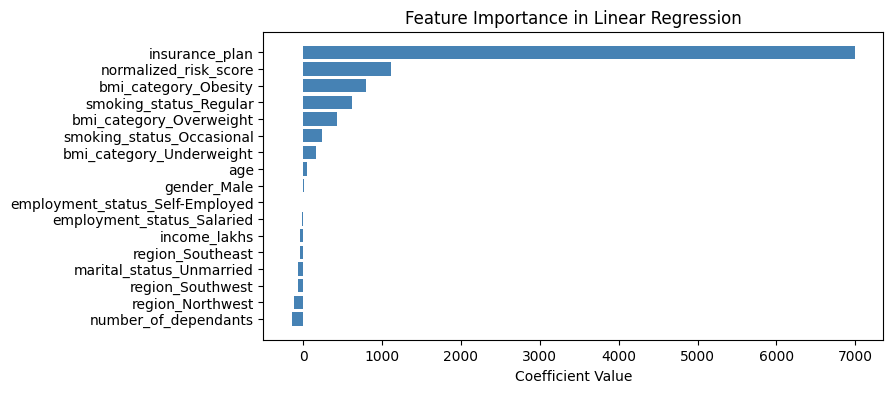

In [234]:
feature_importance = lr_model.coef_

# Create a DataFrame for easier handling
coef_df = pd.DataFrame(feature_importance, index=X_train.columns, columns=['Coefficients'])

# Sort the coefficients for better visualization
coef_df = coef_df.sort_values(by='Coefficients', ascending=True)

# Plotting
plt.figure(figsize=(8, 4))
plt.barh(coef_df.index, coef_df['Coefficients'], color='steelblue')
plt.xlabel('Coefficient Value')
plt.title('Feature Importance in Linear Regression')
plt.show()

In [235]:
coef_df['Coefficients'].sort_values(ascending=False)

insurance_plan                     7000.070416
normalized_risk_score              1111.278786
bmi_category_Obesity                792.952660
smoking_status_Regular              619.082947
bmi_category_Overweight             435.760406
smoking_status_Occasional           244.813937
bmi_category_Underweight            169.728916
age                                  55.190515
gender_Male                           9.825648
employment_status_Self-Employed      -4.342722
employment_status_Salaried          -13.053549
income_lakhs                        -36.066768
region_Southeast                    -36.466371
marital_status_Unmarried            -58.534342
region_Southwest                    -67.223225
region_Northwest                   -114.273450
number_of_dependants               -145.039643
Name: Coefficients, dtype: float64

### Ridge/Lasso/ElasticNet Regression Model

In [236]:
model_rg = Ridge(alpha=1)

model_rg.fit(X_train, y_train)

y_pred_rg = model_rg.predict(X_test)

mse = mean_squared_error(y_test, y_pred_rg)
mae = mean_absolute_error(y_test, y_pred_rg)
rmse = np.sqrt(mse)

score = r2_score(y_test,y_pred_rg)

print("Mean absolute error :", mse)
print("MAE :", mae)
print("RMSE :", rmse)
print('------------------------------------')

print("R2 Score: ", score)
print("adjusted R-squared: ", 1 - (1-score)*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-1))
print('------------------------------------')

print("RMSE / mean:", rmse / df['annual_premium_amount'].mean())
print("RMSE / median:", rmse / df['annual_premium_amount'].median())
print("RMSE / max:", rmse / df['annual_premium_amount'].max())
print('------------------------------------')

Mean absolute error : 3005573.9638324636
MAE : 1507.4016564033677
RMSE : 1733.6591256162394
------------------------------------
R2 Score:  0.6047715291063815
adjusted R-squared:  0.6036532062027212
------------------------------------
RMSE / mean: 0.2129254026000024
RMSE / median: 0.2183724808686534
RMSE / max: 0.09532932616387547
------------------------------------


In [237]:
lasso=Lasso()

lasso.fit(X_train, y_train)
y_pred_lasso = lasso.predict(X_test)

mse = mean_squared_error(y_test, y_pred_lasso)
mae = mean_absolute_error(y_test, y_pred_lasso)
rmse = np.sqrt(mse)

score = r2_score(y_test,y_pred_lasso)

print("Mean absolute error :", mse)
print("MAE :", mae)
print("RMSE :", rmse)
print('------------------------------------')

print("R2 Score: ", score)
print("adjusted R-squared: ", 1 - (1-score)*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-1))
print('------------------------------------')

print("RMSE / mean:", rmse / df['annual_premium_amount'].mean())
print("RMSE / median:", rmse / df['annual_premium_amount'].median())
print("RMSE / max:", rmse / df['annual_premium_amount'].max())
print('------------------------------------')

Mean absolute error : 3003433.0977110174
MAE : 1507.1337431812565
RMSE : 1733.041574143857
------------------------------------
R2 Score:  0.6050530497921969
adjusted R-squared:  0.6039355234683732
------------------------------------
RMSE / mean: 0.21284955585831
RMSE / median: 0.21829469380827018
RMSE / max: 0.09529536864312421
------------------------------------


In [238]:
from sklearn.linear_model import LassoCV

lassocv = LassoCV(
    alphas=100,      # automatically generate
    cv=5,
    max_iter=10000
)

lassocv.fit(X_train, y_train)
y_pred_lassocv = lassocv.predict(X_test)


mse = mean_squared_error(y_test, y_pred_lassocv)
mae = mean_absolute_error(y_test, y_pred_lassocv)
rmse = np.sqrt(mse)

score = r2_score(y_test, y_pred_lassocv)

print("Best alpha:", lassocv.alpha_)
print('------------------------------------')

print("Mean absolute error :", mse)
print("MAE :", mae)
print("RMSE :", rmse)
print('------------------------------------')

print("R2 Score: ", score)
print("adjusted R-squared: ", 1 - (1-score)*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-1))
print('------------------------------------')

print("RMSE / mean:", rmse / df['annual_premium_amount'].mean())
print("RMSE / median:", rmse / df['annual_premium_amount'].median())
print("RMSE / max:", rmse / df['annual_premium_amount'].max())
print('------------------------------------')

Best alpha: 1.3447023496659214
------------------------------------
Mean absolute error : 3002895.2779452465
MAE : 1507.0649938213844
RMSE : 1732.8864007618176
------------------------------------
R2 Score:  0.6051237722852048
adjusted R-squared:  0.6040064460749598
------------------------------------
RMSE / mean: 0.2128304976972475
RMSE / median: 0.21827514809948578
RMSE / max: 0.09528683606960396
------------------------------------


In [239]:
elastic_cv = ElasticNetCV(
    l1_ratio=[0.1,0.3,0.5,0.7,0.9,1],
    alphas=100,
    cv=5,
    random_state=42
)

elastic_cv.fit(X_train, y_train)
y_pred_elastic = elastic_cv.predict(X_test)

r2_score(y_test,y_pred_elastic)

mse = mean_squared_error(y_test, y_pred_elastic)
mae = mean_absolute_error(y_test, y_pred_elastic)
rmse = np.sqrt(mse)

score = r2_score(y_test,y_pred_elastic)

print("Best alpha:", elastic_cv.alpha_)
print("Best l1_ratio:", elastic_cv.l1_ratio_)
print('------------------------------------')

print("Mean absolute error :", mse)
print("MAE :", mae)
print("RMSE :", rmse)
print('------------------------------------')

print("R2 Score: ", score)
print("adjusted R-squared: ", 1 - (1-score)*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-1))
print('------------------------------------')

print("RMSE / mean:", rmse / df['annual_premium_amount'].mean())
print("RMSE / median:", rmse / df['annual_premium_amount'].median())
print("RMSE / max:", rmse / df['annual_premium_amount'].max())
print('------------------------------------')

Best alpha: 1.3447023496659214
Best l1_ratio: 1.0
------------------------------------
Mean absolute error : 3002895.2779452465
MAE : 1507.0649938213844
RMSE : 1732.8864007618176
------------------------------------
R2 Score:  0.6051237722852048
adjusted R-squared:  0.6040064460749598
------------------------------------
RMSE / mean: 0.2128304976972475
RMSE / median: 0.21827514809948578
RMSE / max: 0.09528683606960396
------------------------------------


### XGBRegressor

In [240]:
from xgboost import XGBRegressor

model_xgb = XGBRegressor()
# model_xgb = XGBRegressor(n_estimators=20, max_depth=3)
model_xgb.fit(X_train, y_train)
train_score= model_xgb.score(X_train, y_train)
test_score= model_xgb.score(X_test, y_test)
train_score, test_score


(0.7251046895980835, 0.5638787746429443)

In [241]:
y_pred_xg = model_xgb.predict(X_test)

mse = mean_squared_error(y_test, y_pred_xg)
mae = mean_absolute_error(y_test, y_pred_xg)
rmse = np.sqrt(mse)

score = r2_score(y_test,y_pred_xg)

print("Mean absolute error :", mse)
print("MAE :", mae)
print("RMSE :", rmse)
print('------------------------------------')

print("R2 Score: ", score)
print("adjusted R-squared: ", 1 - (1-score)*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-1))
print('------------------------------------')

print("RMSE / mean:", rmse / df['annual_premium_amount'].mean())
print("RMSE / median:", rmse / df['annual_premium_amount'].median())
print("RMSE / max:", rmse / df['annual_premium_amount'].max())
print('------------------------------------')

Mean absolute error : 3316549.0
MAE : 1554.6983642578125
RMSE : 1821.1394784584731
------------------------------------
R2 Score:  0.5638787746429443
adjusted R-squared:  0.562644743213006
------------------------------------
RMSE / mean: 0.22366960777465109
RMSE / median: 0.2293915453405307
RMSE / max: 0.10013963919820043
------------------------------------


In [242]:
model_xgb = XGBRegressor()

param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 4, 5, 6],
    'min_child_weight': [1, 3, 5],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'gamma': [0, 0.1, 0.3]
}

random_search = RandomizedSearchCV(model_xgb, param_grid, n_iter=10, cv=3, scoring='r2', random_state=42, n_jobs=-1)
random_search.fit(X_train, y_train)
random_search.best_score_

np.float64(0.5981257955233256)

In [243]:
random_search.best_params_

{'subsample': 0.7,
 'n_estimators': 100,
 'min_child_weight': 3,
 'max_depth': 3,
 'learning_rate': 0.1,
 'gamma': 0,
 'colsample_bytree': 1.0}

In [244]:
from sklearn.model_selection import GridSearchCV

model_xgb = XGBRegressor()

param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'gamma': [0, 0.1, 0.3]
}

grid_search = GridSearchCV(
    estimator=model_xgb,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_train, y_train)
grid_search.best_score_

Fitting 5 folds for each of 96 candidates, totalling 480 fits


np.float64(0.5996110796928406)

In [245]:
grid_search.best_params_

{'colsample_bytree': 1.0,
 'gamma': 0,
 'learning_rate': 0.05,
 'max_depth': 3,
 'n_estimators': 100,
 'subsample': 1.0}

In [246]:
best_model = elastic_cv

## Error Analysis

In [247]:
X_test.shape

(6026, 17)

In [248]:
y_pred = best_model.predict(X_test)

residuals = y_pred-y_test
residuals_per = residuals*100/y_test

results_df = pd.DataFrame({
    'actual': y_test, 
    'predicted': y_pred, 
    'diff': residuals, 
    'diff_pct': residuals_per
})
results_df.head(15)


,actual,predicted,diff,diff_pct
12774,6238,6642.663236,404.663236,6.487067
14758,9462,7123.665370,-2338.334630,-24.712900
13205,5152,7070.558767,1918.558767,37.239106
14278,6988,7910.835163,922.835163,13.205998
19351,4917,6686.853458,1769.853458,35.994579
10622,8947,7325.606323,-1621.393677,-18.122205
16391,10437,10061.330406,-375.669594,-3.599402
14799,9769,7596.041277,-2172.958723,-22.243410
17184,7102,6655.226981,-446.773019,-6.290806
16348,6122,7165.932115,1043.932115,17.052142


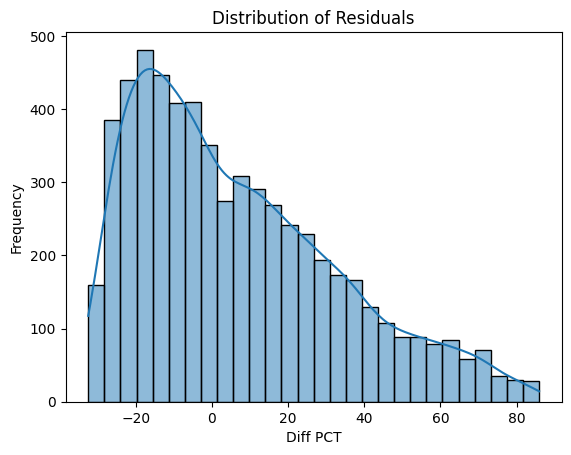

In [249]:
sns.histplot(results_df['diff_pct'], kde=True)
plt.title('Distribution of Residuals')
plt.xlabel('Diff PCT')
plt.ylabel('Frequency')
plt.show()

Most of the prediction errors fall between **-20 and 20**, but there are a few outliers where the error reaches up to **80%**.

In [250]:
X_test.shape

(6026, 17)

In [251]:
results_df.shape

(6026, 4)

In [252]:
extreme_error_threshold = 10  # You can adjust this threshold based on your domain knowledge or requirements
extreme_results_df = results_df[np.abs(results_df['diff_pct']) > extreme_error_threshold]
extreme_results_df.head()

,actual,predicted,diff,diff_pct
14758,9462,7123.665370,-2338.334630,-24.712900
13205,5152,7070.558767,1918.558767,37.239106
14278,6988,7910.835163,922.835163,13.205998
19351,4917,6686.853458,1769.853458,35.994579
10622,8947,7325.606323,-1621.393677,-18.122205


In [253]:
extreme_results_df.shape

(4406, 4)

In [254]:
extreme_errors_pct = extreme_results_df.shape[0]*100/X_test.shape[0]
extreme_errors_pct

73.11649518752074

We have **73% extreme errors**, which means for **73% of customers** the prediction will either **overcharge or undercharge by 10% or more**.

In [255]:
extreme_results_df[abs(extreme_results_df.diff_pct)>50].sort_values("diff_pct",ascending=False)

,actual,predicted,diff,diff_pct
3652,3536,6573.944507,3037.944507,85.914720
16580,3538,6567.062804,3029.062804,85.615116
10288,3623,6724.800503,3101.800503,85.614146
17084,3562,6585.628850,3023.628850,84.885706
12285,3532,6524.684562,2992.684562,84.730593
...,...,...,...,...
14024,4415,6630.052926,2215.052926,50.171074
2102,4334,6507.287959,2173.287959,50.145084
1597,4653,6985.870059,2332.870059,50.136902
19225,4615,6927.455084,2312.455084,50.107369


Approximately **523 customers** are expected to experience **errors greater than 50%**, resulting in significant overcharging or undercharging.

### We cannot deploy this model, first we need to fixed the extreme errros

In [256]:
extreme_errors_df = X_test.loc[extreme_results_df.index]
extreme_errors_df.head(2)

,age,number_of_dependants,income_lakhs,insurance_plan,normalized_risk_score,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
14758,0.285714,0.000000,0.060606,0.0,0.0,0,0,0,1,1,0,0,0,0,1,0,1
13205,0.714286,0.333333,0.141414,0.0,0.0,1,1,0,0,1,0,0,0,0,1,0,1


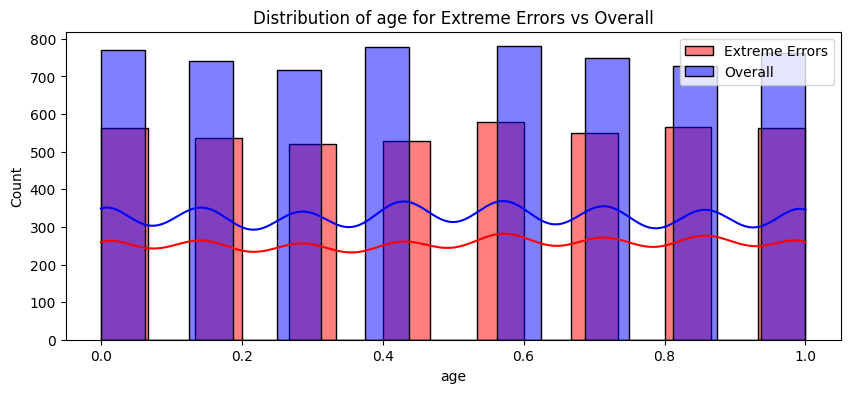

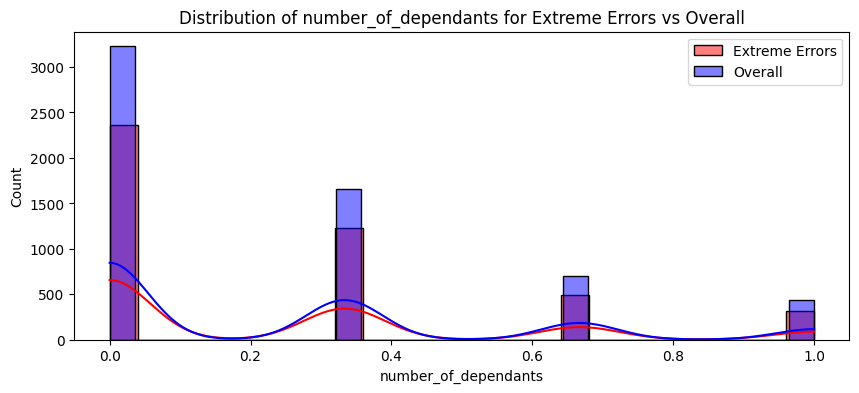

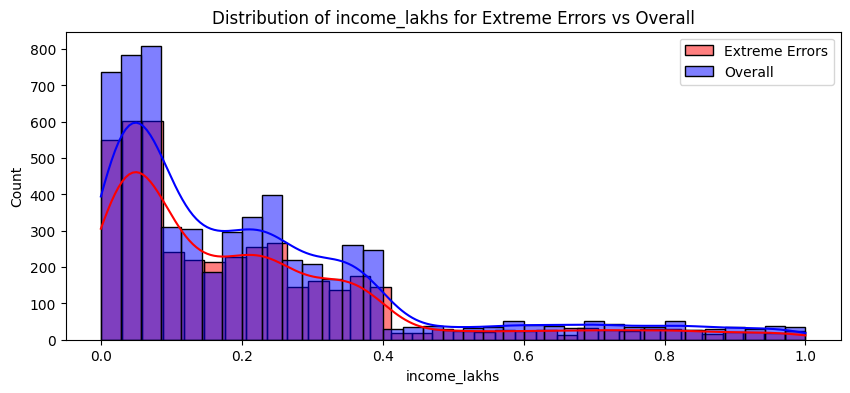

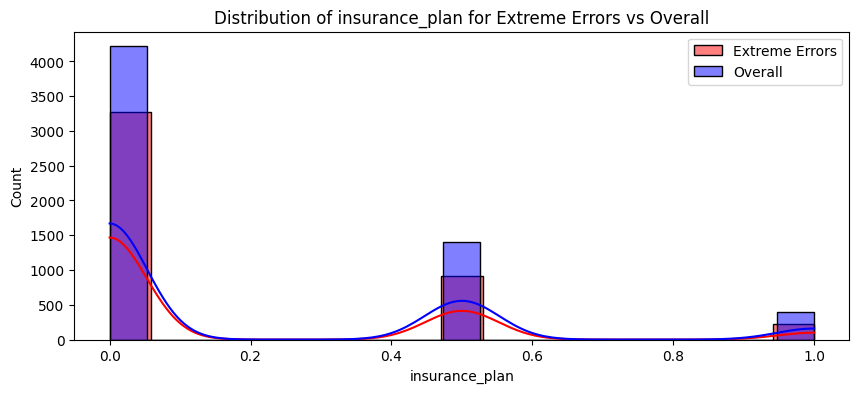

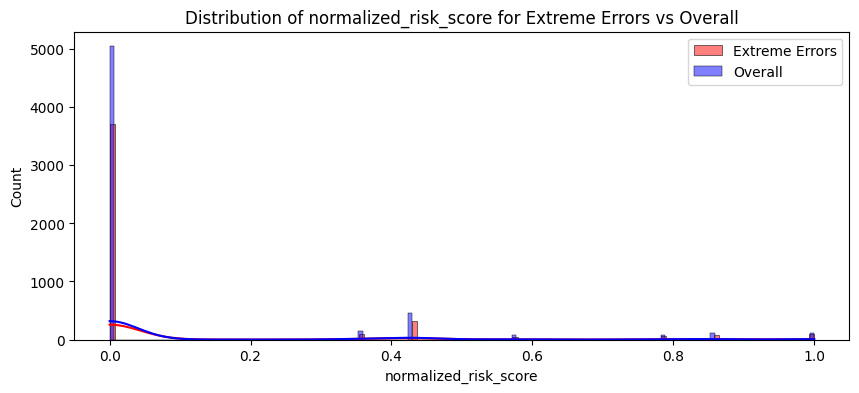

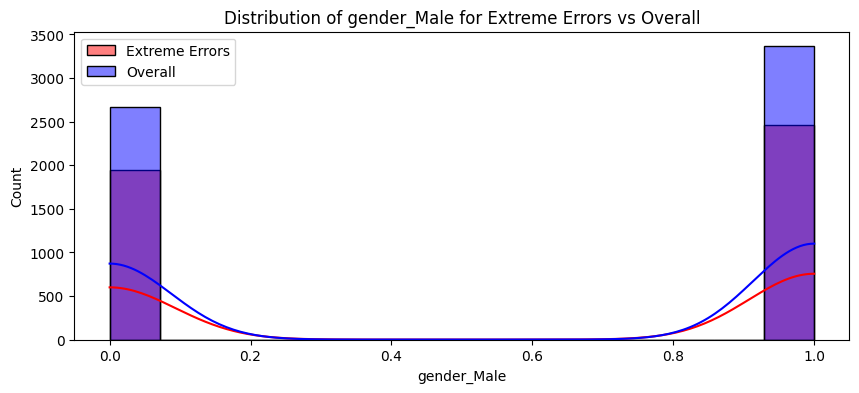

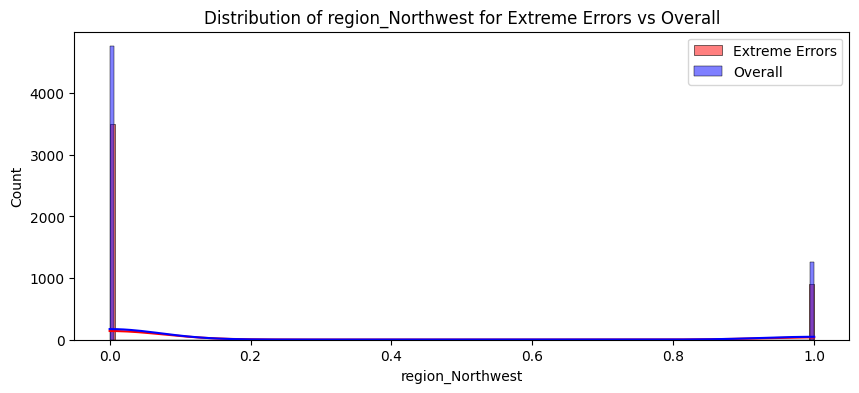

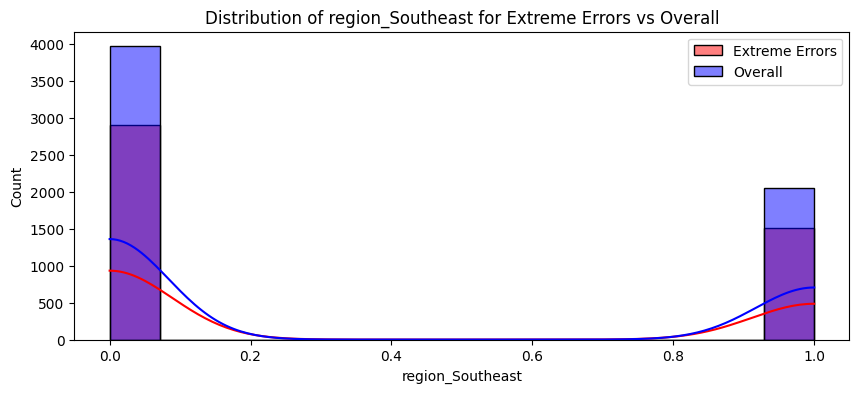

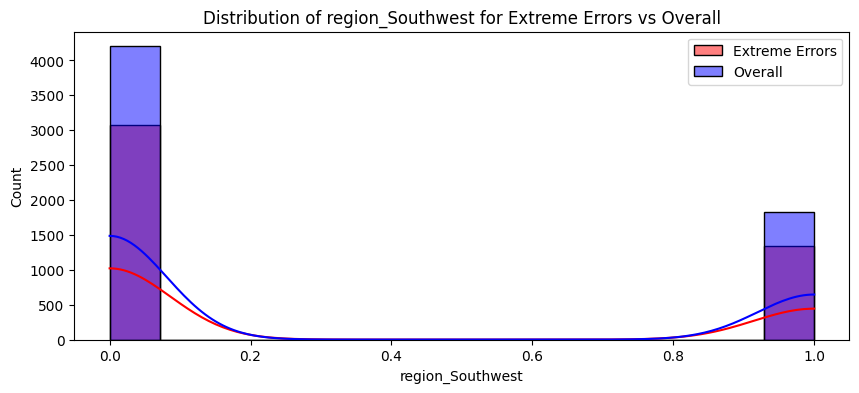

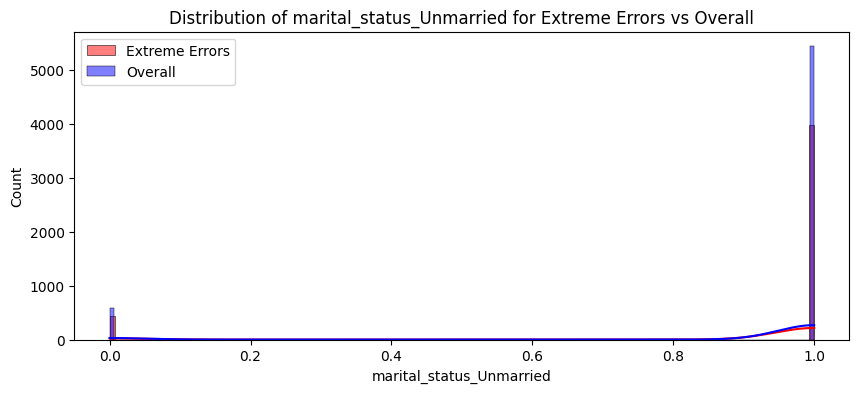

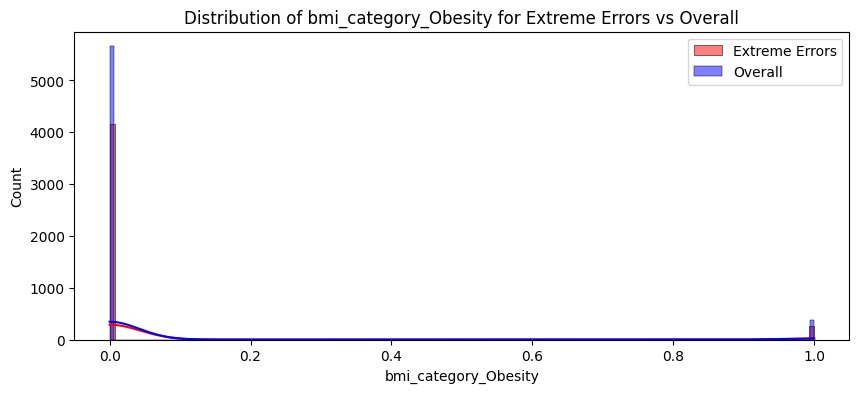

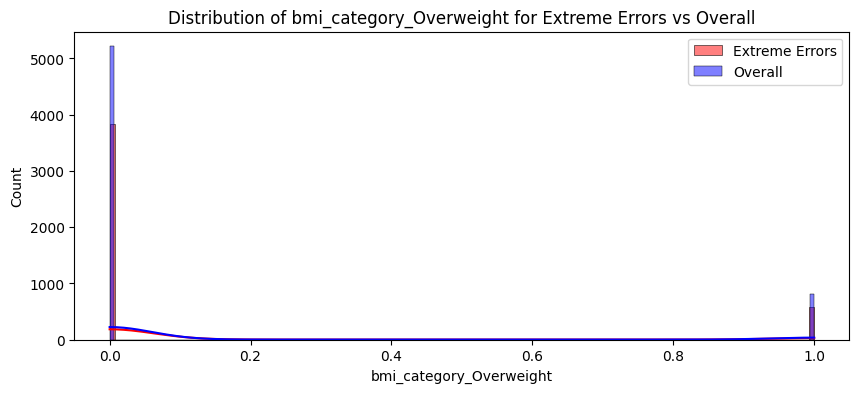

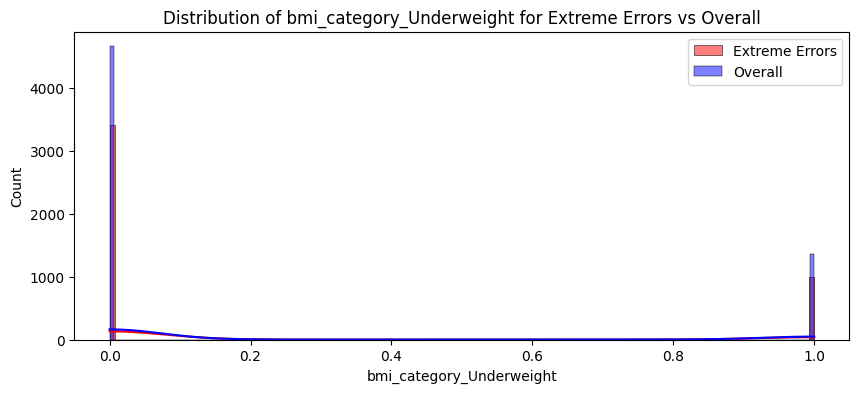

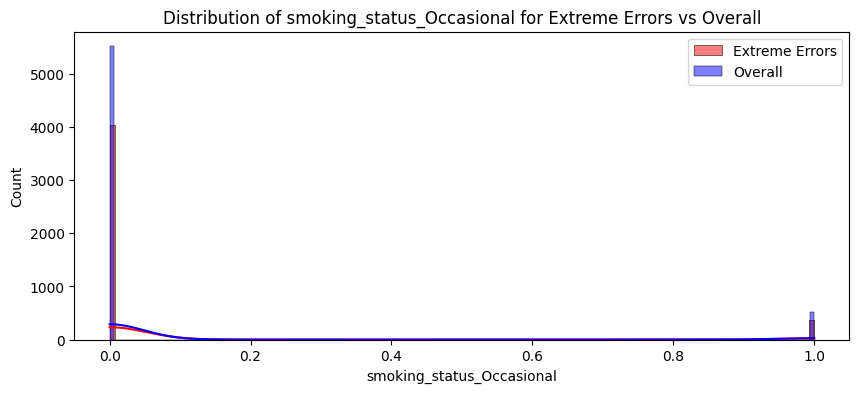

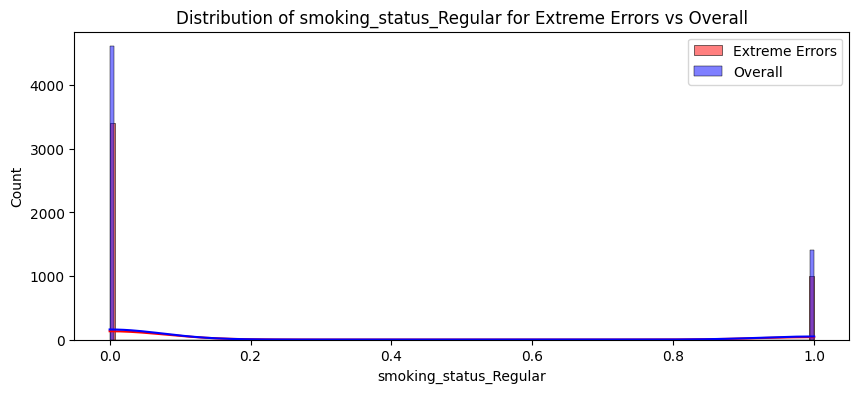

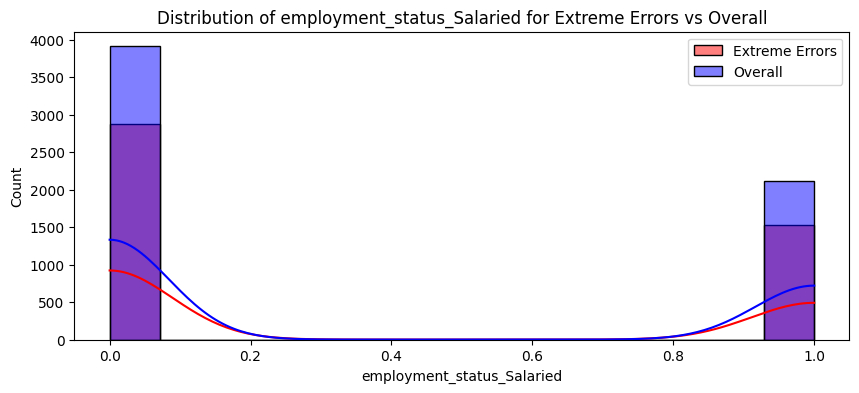

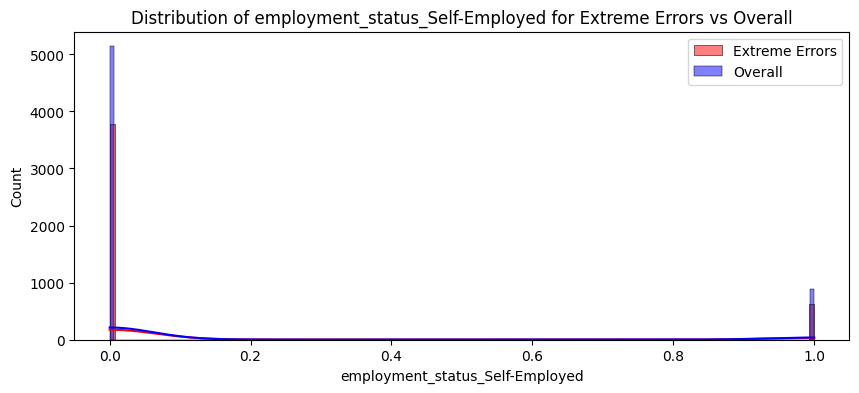

In [257]:
for feature in X_test.columns:
    plt.figure(figsize=(10, 4))
    sns.histplot(extreme_errors_df[feature], color='red', label='Extreme Errors', kde=True)
    sns.histplot(X_test[feature], color='blue', label='Overall', alpha=0.5, kde=True)
    plt.legend()
    plt.title(f'Distribution of {feature} for Extreme Errors vs Overall')
    plt.show()

I have error in multiple columns, but age column has large errors

<Axes: xlabel='age', ylabel='Count'>

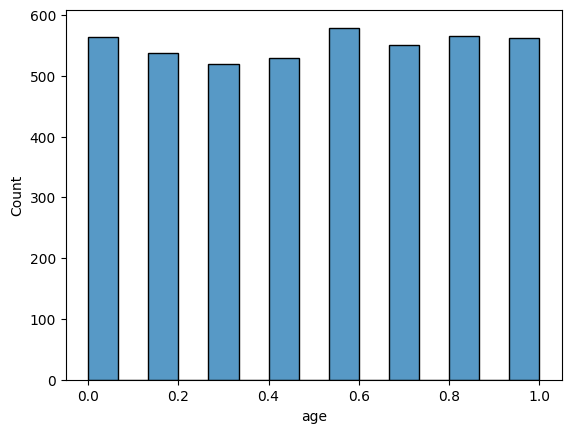

In [258]:
sns.histplot(extreme_errors_df.age)

### Reverse Scaling: scaling back to see which age group has problem

In [259]:
extreme_errors_df['income_level']=-1

In [260]:
df_reversed = pd.DataFrame()
df_reversed[cols_to_scale] = scaler.inverse_transform(extreme_errors_df[cols_to_scale])
df_reversed.head()

,age,number_of_dependants,income_level,income_lakhs,insurance_plan
0,20.0,0.0,-2.0,7.0,1.0
1,23.0,1.0,-2.0,15.0,1.0
2,23.0,1.0,-2.0,23.0,1.0
3,22.0,0.0,-2.0,11.0,1.0
4,21.0,1.0,-2.0,6.0,1.0


In [261]:
df_reversed.describe()

,age,number_of_dependants,income_level,income_lakhs,insurance_plan
count,4406.000000,4406.000000,4406.0,4406.000000,4406.000000
mean,21.531321,0.718566,-2.0,21.508171,1.308443
std,2.302404,0.925490,0.0,20.974181,0.559679
min,18.000000,0.000000,-2.0,1.000000,1.000000
25%,20.000000,0.000000,-2.0,6.000000,1.000000
50%,22.000000,0.000000,-2.0,15.000000,1.000000
75%,24.000000,1.000000,-2.0,30.000000,2.000000
max,25.000000,3.000000,-2.0,100.000000,3.000000


<Axes: xlabel='age', ylabel='Count'>

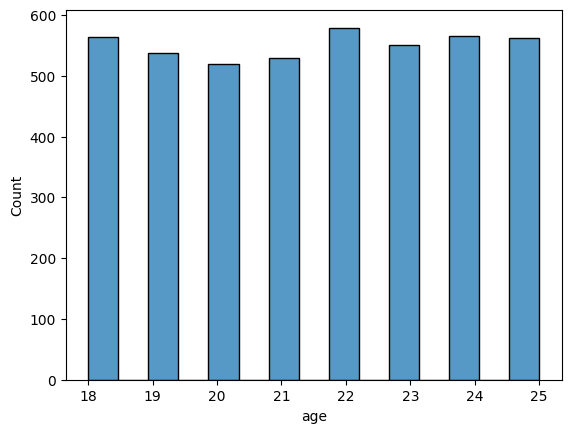

In [262]:
sns.histplot(df_reversed.age)

In [263]:
df_reversed['age'].quantile(0.97)

np.float64(25.0)

This means that **97% of the extreme errors** occur for customers who are **25 years old or younger**.